# Preterm Birth Model Build — Train 2021–2023 / External Test 2024

Builds, tunes, gates, and reports on a LightGBM classifier for `preterm_oe`,
following on from the exploratory analysis in `01_eda_natality_preterm.ipynb`.

**Design notes:**

1. **Model promotion gate.** Promotion to champion status requires meeting
   three literature-grounded thresholds (AUC, minority-class F1, and macro
   F1), documented in the "Model promotion gate" section below, together
   with a rolling run-history log. Reporting is kept consistent throughout:
   a single dense summary line, a `classification_report`-style table, and
   explicit `GATE PASSED` / `GATE FAILED` language against the run history.
2. **Class imbalance.** This notebook uses `scale_pos_weight` as the default
   approach to the roughly 10% positive rate (see the "Class imbalance"
   section for the reasoning), with a `USE_SMOTE` toggle available for a
   side-by-side comparison against synthetic oversampling. Cost-sensitive
   weighting is used as the default because it is typically competitive
   with, or superior to, synthetic oversampling for gradient-boosted trees
   at this data scale.

**Runtime note:** the training set is approximately 11 million rows.
Hyperparameter search runs on a stratified subsample (`SEARCH_SAMPLE_SIZE`)
for tractability, and the winning configuration is then refit on the full
2021–2023 training set. Every runtime-control knob is set in the
configuration cell below.

In [1]:
import sys, os, json, time, warnings
sys.path.insert(0, r"C:\Users\abiol\projects\Preterm\data")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score, accuracy_score,
    f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import joblib

import lightgbm as lgb
try:
    import shap
    HAVE_SHAP = True
except ImportError:
    HAVE_SHAP = False
    print("shap not installed -- the SHAP section will be skipped. `pip install shap` to enable it.")

import feature_engineer_natality as fe

DATA_DIR = fe.DATA_DIR
TRAIN_YEARS = fe.TRAIN_YEARS
TEST_YEAR = fe.TEST_YEAR
TARGET = fe.PRIMARY_TARGET
RANDOM_STATE = 42

# --- runtime-control knobs -- adjust based on available compute ---
SEARCH_SAMPLE_SIZE = 500_000   # rows used for RandomizedSearchCV; full refit happens after, on all of train_fit
N_ITER_SEARCH = 25
CV_FOLDS = 3
SHAP_SAMPLE_SIZE = 5_000
USE_SMOTE = False              # see "Class imbalance" section below before flipping this on

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 4)

## 1. Load data and split

In [2]:
train_full = fe.load_years(TRAIN_YEARS, DATA_DIR)
test_df = fe.load_years([TEST_YEAR], DATA_DIR)

X_full, y_full = fe.get_model_matrix(train_full, target=TARGET)
X_test, y_test = fe.get_model_matrix(test_df, target=TARGET)

print(f"Full train ({TRAIN_YEARS}): {X_full.shape}, positive rate {y_full.mean():.4%}")
print(f"Held-out test ({TEST_YEAR}):   {X_test.shape}, positive rate {y_test.mean():.4%}")

Loaded years [2021, 2022, 2023]: 10,951,038 rows, 2,037 MB in memory
Loaded years [2024]: 3,638,436 rows, 677 MB in memory
Full train ([2021, 2022, 2023]): (10951038, 79), positive rate 10.4130%
Held-out test (2024):   (3638436, 79), positive rate 10.3877%


80/20 split of the **training years only**, stratified on the target, for
fit/calibration -- this is what gets used to pick a decision threshold before
ever touching 2024. 2024 stays completely untouched until the final
evaluation section.

In [3]:
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=RANDOM_STATE
)
print(f"Fit set:   {X_fit.shape}, positive rate {y_fit.mean():.4%}")
print(f"Calib set: {X_calib.shape}, positive rate {y_calib.mean():.4%}")

Fit set:   (8760830, 79), positive rate 10.4130%
Calib set: (2190208, 79), positive rate 10.4130%


## 2. Feature review -- interaction term and a correlation screen

Adds an explicit `rf_ppterm x dplural` interaction term: prior preterm birth
compounded by multiple gestation is a well-established combined risk factor
in the clinical literature, not simply two independent risk factors. Also
runs a numeric correlation screen so that highly redundant predictor pairs
are visible before modeling. Gradient boosting is comparatively robust to
multicollinearity relative to linear models, so nothing is automatically
dropped on the basis of this screen alone -- it is retained as a
diagnostic, with any exclusion decision made and documented explicitly at
the point it is applied, based on the bivariate patterns observed during
exploratory analysis.

In [4]:
def add_interactions(df):
    df = df.copy()
    if {"rf_ppterm", "dplural"}.issubset(df.columns):
        multi_gestation = (df["dplural"].astype("float") > 1).astype("Int8")
        prior_preterm = df["rf_ppterm"].fillna(0).astype("int8")
        df["rf_ppterm_x_multiple_gestation"] = (
            prior_preterm & multi_gestation.fillna(0).astype("int8")
        ).astype("Int8")
    return df

X_fit = add_interactions(X_fit)
X_calib = add_interactions(X_calib)
X_test = add_interactions(X_test)
X_full = add_interactions(X_full)

print(f"rf_ppterm_x_multiple_gestation positive rate (fit set): "
      f"{X_fit['rf_ppterm_x_multiple_gestation'].mean():.4%}")

rf_ppterm_x_multiple_gestation positive rate (fit set): 0.2061%


In [5]:
categorical_cols = [c for c in X_fit.columns if X_fit[c].dtype.name in ("category", "object")]
numeric_cols = [c for c in X_fit.columns if c not in categorical_cols]

corr = X_fit[numeric_cols].astype("float32").corr().abs()
high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.8]
print(f"{len(categorical_cols)} categorical columns, {len(numeric_cols)} numeric columns.")
print("\nNumeric pairs with |correlation| > 0.8 (diagnostic only -- see markdown above):")
print(high_corr_pairs if len(high_corr_pairs) else "  none found")

9 categorical columns, 71 numeric columns.

Numeric pairs with |correlation| > 0.8 (diagnostic only -- see markdown above):
wic_reported  pay_rec_reported           1.000000
f_rf_ghyper   rf_ghype_reported          1.000000
f_rf_phyper   pay_rec_reported           1.000000
              wic_reported               1.000000
              rf_cesar_reported          1.000000
                                           ...   
cig_1         cig_2                      0.891545
priorterm     prior_pregnancies_total    0.865178
priorlive     prior_pregnancies_total    0.864057
cig_1         cig_3                      0.826888
cig_0         cig_1                      0.815129
Length: 575, dtype: float64


In [6]:
# Missing-not-at-random check: the EDA notebook found that wtgain, bmi,
# precare, meduc, previs, and wic are NOT missing independently -- 22,830
# rows in the training years share the *exact same* not-reported pattern
# across all six fields simultaneously. Confirming that here on the actual
# feature matrix, via the *_reported flags feature_engineer_natality.py
# already builds, before trusting each field's missingness as an
# independent signal in the model.
reported_cols = [c for c in fe.REPORTED_COLS if c in X_fit.columns]
if reported_cols:
    reported_corr = X_fit[reported_cols].astype("float32").corr()
    print("Correlation among *_reported flags (near 1.0 = missing/present together):")
    print(reported_corr.round(2))
else:
    print("No *_reported columns found in the feature matrix -- skipping.")

Correlation among *_reported flags (near 1.0 = missing/present together):
                    meduc_reported  dmar_reported  precare_reported  \
meduc_reported                1.00           0.13              1.00   
dmar_reported                 0.13           1.00              0.13   
precare_reported              1.00           0.13              1.00   
previs_reported               1.00           0.13              1.00   
cig_0_reported                1.00           0.13              1.00   
cig_1_reported                1.00           0.13              1.00   
cig_2_reported                1.00           0.13              1.00   
cig_3_reported                1.00           0.13              1.00   
bmi_reported                  1.00           0.13              1.00   
wtgain_reported               1.00           0.13              1.00   
rf_pdiab_reported             1.00           0.13              1.00   
rf_gdiab_reported             1.00           0.13              1.00   
rf_

The block above should reproduce the EDA notebook's finding: `wtgain_reported`,
`bmi_reported`, `precare_reported`, `meduc_reported`, `previs_reported`, and
`wic_reported` correlate strongly with each other (missing together as one
batch, not independently), while the other `*_reported` flags stay closer to
uncorrelated. In practice that means those six flags carry mostly redundant
"this record was thin on data" signal rather than six independent
missingness signals -- LightGBM handles the redundancy fine on its own, but
it's worth knowing before reading too much into any single one of those six
flags individually in the feature-importance/SHAP sections below.

**A subtlety in how these two flags are constructed:** `no_prenatal_care`
and `late_prenatal_care` (from `feature_engineer_natality.py`) are built as
`precare == 0` / `precare > 3`. Pandas comparisons against `NaN` return
`False`, so a row with **unknown** `precare` silently lands as `0` on both
flags -- indistinguishable from "precare was in the normal 1-3 month range."
That conflates "no data" with "normal," which is exactly the kind of
missing-not-at-random risk Section 4 of the EDA notebook was checking for.
`precare_reported` (already in the feature set) is the correct way to
separate those two cases -- worth keeping as an explicit predictor alongside
these two flags rather than trusting them alone.

## 3. Preprocessing -- median / most-frequent imputation, native categoricals

A small pandas-native imputer (median for numeric, mode for categorical),
fit only on the training fold each time to avoid leakage. Categorical
columns stay `category` dtype after imputation rather than being one-hot
encoded -- LightGBM takes pandas `category` columns natively, which matters
at this row count (one-hot on `mrace31`/`pay_rec` etc. across 11M rows would
be a lot of unnecessary width and memory for no accuracy benefit with a
tree-based model).

In [7]:
class MedianModeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, drop_cols=None):
        # drop_cols: columns to exclude entirely (e.g. for an ablation/actionability
        # check) -- excluded during fit AND dropped from transform's output, so the
        # caller never needs to pre-copy X with that column removed (see Section 8c
        # for why that matters at this row count).
        # NB: stored as-is (sklearn's clone() requires __init__ not transform its
        # arguments) -- normalize to a list only where it's actually used, in fit().
        self.drop_cols = drop_cols

    def fit(self, X, y=None):
        drop_cols = list(self.drop_cols) if self.drop_cols else []
        use_cols = [c for c in X.columns if c not in drop_cols]
        self.categorical_cols_ = [c for c in use_cols if X[c].dtype.name in ("category", "object")]
        self.numeric_cols_ = [c for c in use_cols if c not in self.categorical_cols_]
        # per-column median (not X[numeric_cols].astype("float64").median()) -- casting
        # every numeric column to float64 and consolidating into one block at once
        # peaks at several GB extra at ~9M rows; a column at a time keeps the
        # transient footprint to one column's worth.
        self.medians_ = pd.Series({c: X[c].astype("float64").median() for c in self.numeric_cols_})
        self.modes_ = X[self.categorical_cols_].mode().iloc[0] if self.categorical_cols_ else pd.Series(dtype=object)
        return self

    def transform(self, X):
        X = X[self.numeric_cols_ + self.categorical_cols_].copy()
        for c in self.numeric_cols_:
            X[c] = X[c].astype("float32").fillna(self.medians_[c])
        for c in self.categorical_cols_:
            fill_val = self.modes_[c]
            if X[c].dtype.name == "category" and fill_val not in X[c].cat.categories:
                X[c] = X[c].cat.add_categories([fill_val])
            X[c] = X[c].fillna(fill_val)
        return X

## 4. Class imbalance -- `scale_pos_weight` by default, `SMOTE` as an opt-in comparison

A ~10.4% positive rate is moderate imbalance, not extreme. At ~11M rows of
mostly categorical/count-coded features (not smooth continuous ones), doing
oversampling properly requires `SMOTENC` (the mixed-type variant of SMOTE),
which is expensive at this scale and, in practice, rarely beats a
well-tuned `scale_pos_weight` for gradient boosting on tabular data of this
size. `scale_pos_weight` is therefore the default here. `USE_SMOTE = True`
(config cell) runs a `SMOTENC` path on the same search subsample so the two
approaches can be compared empirically rather than the choice being taken
on faith.

In [8]:
n_pos = int(y_fit.sum())
n_neg = int(len(y_fit) - n_pos)
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (n_neg/n_pos) on the fit set: {scale_pos_weight:.3f}")

if USE_SMOTE:
    from imblearn.over_sampling import SMOTENC
    rng = np.random.RandomState(RANDOM_STATE)
    smote_idx = rng.choice(len(X_fit), size=min(SEARCH_SAMPLE_SIZE, len(X_fit)), replace=False)
    X_smote_in = MedianModeImputer().fit(X_fit).transform(X_fit.iloc[smote_idx])
    cat_idx = [X_smote_in.columns.get_loc(c) for c in categorical_cols]
    # SMOTENC needs plain numeric codes for categoricals, not pandas 'category' dtype
    X_smote_in_enc = X_smote_in.copy()
    for c in categorical_cols:
        X_smote_in_enc[c] = X_smote_in_enc[c].cat.codes
    sm = SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE)
    X_res, y_res = sm.fit_resample(X_smote_in_enc, y_fit.iloc[smote_idx])
    print(f"SMOTENC (on a {len(smote_idx):,}-row subsample): {X_fit.iloc[smote_idx].shape} -> "
          f"{X_res.shape}, positive rate {y_res.mean():.4%}")
    print("This path is for comparison only in this notebook -- the champion model below is "
          "still trained with scale_pos_weight, not on the SMOTE-resampled data. A "
          "head-to-head comparison would require fitting a parallel model on X_res/y_res.")
else:
    print("USE_SMOTE=False -- proceeding with scale_pos_weight only.")

scale_pos_weight (n_neg/n_pos) on the fit set: 8.603
USE_SMOTE=False -- proceeding with scale_pos_weight only.


## 5. Hyperparameter search (subsample)

`RandomizedSearchCV` on a stratified-size subsample for tractability, scored
by `roc_auc` (standard binary ROC-AUC -- this is a strictly binary
classification problem, so the plain scorer is used rather than a
multiclass-oriented one). LightGBM auto-detects pandas `category` dtype
columns as categorical without needing an explicit `categorical_feature`
argument -- worth a quick sanity check after fitting that it actually
picked them up (done below).

In [9]:
# n_jobs=1 on the model here deliberately -- RandomizedSearchCV below already
# parallelizes across param/fold combinations with n_jobs=-1, and nesting
# LightGBM's own multi-threading inside that oversubscribes CPU and can hang
# (not just slow down) rather than crash cleanly. Parallelize at one level
# only. The full-refit LGBMClassifier further down (a single fit, not wrapped
# in a search) uses n_jobs=-1 since there's no outer parallelism to conflict with.
pipeline = Pipeline([
    ("preprocess", MedianModeImputer()),
    ("model", lgb.LGBMClassifier(
        objective="binary", scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=1, verbosity=-1,
    )),
])

rng = np.random.RandomState(RANDOM_STATE)
search_idx = rng.choice(len(X_fit), size=min(SEARCH_SAMPLE_SIZE, len(X_fit)), replace=False)
X_search, y_search = X_fit.iloc[search_idx], y_fit.iloc[search_idx]
print(f"Hyperparameter search on a {len(X_search):,}-row subsample "
      f"(full-data refit happens in the next cell).")

param_distributions = {
    "model__num_leaves": [15, 31, 63, 95, 127],
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__min_child_samples": [10, 20, 50, 100],
    "model__reg_lambda": [0.0, 0.1, 1.0, 5.0],
}

search = RandomizedSearchCV(
    pipeline, param_distributions=param_distributions, n_iter=N_ITER_SEARCH,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1, refit=True,
)
t0 = time.time()
search.fit(X_search, y_search)
print(f"Search done in {time.time()-t0:.1f}s. Best CV AUC on subsample: {search.best_score_:.4f}")

fitted_booster = search.best_estimator_.named_steps["model"]
pandas_categorical = getattr(fitted_booster.booster_, "pandas_categorical", None)
n_detected = len(pandas_categorical) if pandas_categorical else 0
print(f"Categorical columns passed in: {len(categorical_cols)} -- LightGBM recorded "
      f"{n_detected} categorical column(s) internally (booster_.pandas_categorical) -- "
      f"should match if native categorical handling kicked in correctly, not silently "
      f"treating them as raw numeric codes.")

Hyperparameter search on a 500,000-row subsample (full-data refit happens in the next cell).
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Search done in 655.0s. Best CV AUC on subsample: 0.8221
Categorical columns passed in: 9 -- LightGBM recorded 9 categorical column(s) internally (booster_.pandas_categorical) -- should match if native categorical handling kicked in correctly, not silently treating them as raw numeric codes.


In [10]:
cv_results = pd.DataFrame(search.cv_results_)
top10 = (
    cv_results[["mean_test_score", "std_test_score", "params"]]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index = top10.index + 1
top10.index.name = "rank"
print("Top-10 parameter combinations, ranked by mean CV AUC:")
top10

Top-10 parameter combinations, ranked by mean CV AUC:

,mean_test_score,std_test_score,params
rank,,,
1,0.822072,0.000553,"{'model__subsample': 0.8, 'model__reg_lambda':..."
2,0.821917,0.000528,"{'model__subsample': 1.0, 'model__reg_lambda':..."
3,0.821661,0.000402,"{'model__subsample': 0.9, 'model__reg_lambda':..."
4,0.821658,0.000690,"{'model__subsample': 0.6, 'model__reg_lambda':..."
5,0.821438,0.000585,"{'model__subsample': 0.6, 'model__reg_lambda':..."
6,0.821238,0.000451,"{'model__subsample': 0.8, 'model__reg_lambda':..."
7,0.821194,0.000596,"{'model__subsample': 0.6, 'model__reg_lambda':..."
8,0.821018,0.000907,"{'model__subsample': 0.6, 'model__reg_lambda':..."
9,0.820942,0.000787,"{'model__subsample': 0.6, 'model__reg_lambda':..."


## 5b. Does training on all ~8.7M rows actually earn its cost?

This is answered with evidence rather than assumed in either direction.
Two considerations pull in opposite directions: LightGBM's histogram method
scales roughly linearly in rows, so training on all of `X_fit` is not the
kind of quadratic-cost problem that would force subsampling on principle --
but a **uniform** subsample also shrinks the minority (preterm) class in
exact proportion to how much it shrinks the majority class, which cuts
directly against the thing the promotion gate cares about most
(minority-class performance). The champion configuration is therefore fit
at several training sizes (same fixed hyperparameters from the search
above, so this isolates "how much data" from "which hyperparameters"), and
calibration-set AUC/PR-AUC and fit time are checked at each size. If the
curve visibly flattens well before the full row count, that is evidence a
smaller sample would suffice for day-to-day iteration; if it is still
climbing at the full size, that is evidence the full fit below earns its
compute cost. Either way, the answer comes from the empirical curve below
rather than a general rule of thumb.

Best params (from subsample search): {'subsample': 0.8, 'reg_lambda': 0.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
n=   100,000  (preterm examples:   10,397)  fit_time=   3.5s  calib_AUC=0.8181  calib_PR-AUC=0.4440
n=   300,000  (preterm examples:   31,371)  fit_time=  11.0s  calib_AUC=0.8215  calib_PR-AUC=0.4499
n= 1,000,000  (preterm examples:  104,041)  fit_time=  33.7s  calib_AUC=0.8236  calib_PR-AUC=0.4540
n= 3,000,000  (preterm examples:  312,788)  fit_time= 116.1s  calib_AUC=0.8245  calib_PR-AUC=0.4561
n= 8,760,830  (preterm examples:  912,265)  fit_time= 330.9s  calib_AUC=0.8248  calib_PR-AUC=0.4564


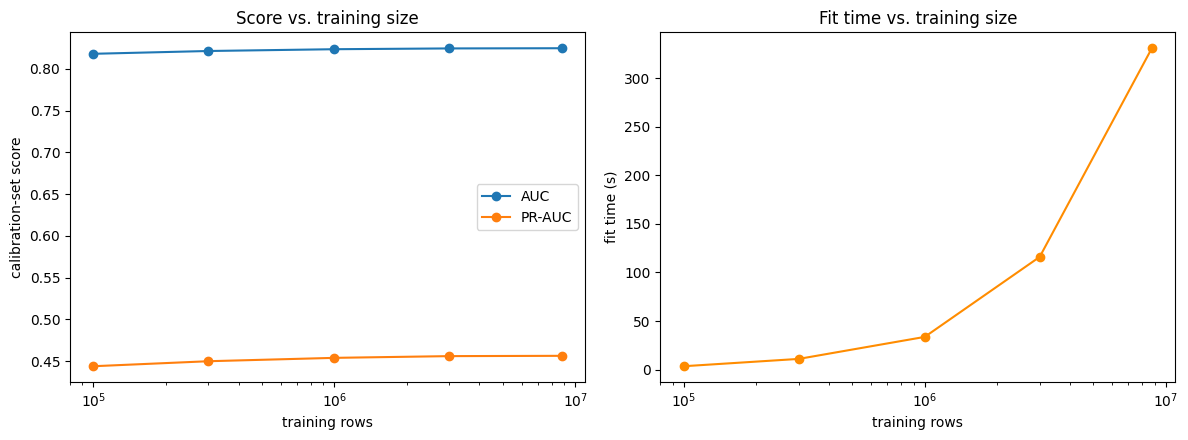

,train_rows,n_preterm_examples,fit_seconds,calib_auc,calib_pr_auc
0,100000,10397,3.476421,0.818120,0.443953
1,300000,31371,11.010413,0.821470,0.449938
2,1000000,104041,33.666732,0.823608,0.453974
3,3000000,312788,116.060874,0.824545,0.456051
4,8760830,912265,330.926544,0.824781,0.456404


In [11]:
best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
print("Best params (from subsample search):", best_params)

learning_curve_sizes = sorted(set(min(n, len(X_fit)) for n in [100_000, 300_000, 1_000_000, 3_000_000, len(X_fit)]))

lc_rows = []
for n in learning_curve_sizes:
    idx = rng.choice(len(X_fit), size=n, replace=False) if n < len(X_fit) else np.arange(len(X_fit))
    X_n, y_n = X_fit.iloc[idx], y_fit.iloc[idx]
    n_pos_n = int(y_n.sum())
    pipe_n = Pipeline([
        ("preprocess", MedianModeImputer()),
        ("model", lgb.LGBMClassifier(
            objective="binary", scale_pos_weight=(len(y_n) - n_pos_n) / n_pos_n,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1, **best_params,
        )),
    ])
    t0 = time.time()
    pipe_n.fit(X_n, y_n)
    fit_seconds = time.time() - t0
    proba_n = pipe_n.predict_proba(X_calib)[:, 1]
    lc_rows.append({
        "train_rows": n, "n_preterm_examples": n_pos_n, "fit_seconds": fit_seconds,
        "calib_auc": roc_auc_score(y_calib, proba_n),
        "calib_pr_auc": average_precision_score(y_calib, proba_n),
    })
    print(f"n={n:>10,}  (preterm examples: {n_pos_n:>8,})  fit_time={fit_seconds:6.1f}s  "
          f"calib_AUC={lc_rows[-1]['calib_auc']:.4f}  calib_PR-AUC={lc_rows[-1]['calib_pr_auc']:.4f}")

lc_df = pd.DataFrame(lc_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(lc_df["train_rows"], lc_df["calib_auc"], marker="o", label="AUC")
axes[0].plot(lc_df["train_rows"], lc_df["calib_pr_auc"], marker="o", label="PR-AUC")
axes[0].set_xscale("log"); axes[0].set_xlabel("training rows"); axes[0].set_ylabel("calibration-set score")
axes[0].set_title("Score vs. training size"); axes[0].legend()
axes[1].plot(lc_df["train_rows"], lc_df["fit_seconds"], marker="o", color="darkorange")
axes[1].set_xscale("log"); axes[1].set_xlabel("training rows"); axes[1].set_ylabel("fit time (s)")
axes[1].set_title("Fit time vs. training size")
plt.tight_layout()
plt.show()
lc_df

## 6. Full refit on all of the training fit-set

In [12]:
best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
print("Best params (from subsample search):", best_params)

final_pipeline = Pipeline([
    ("preprocess", MedianModeImputer()),
    ("model", lgb.LGBMClassifier(
        objective="binary", scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1, **best_params,
    )),
])

t0 = time.time()
final_pipeline.fit(X_fit, y_fit)
print(f"Full refit on {len(X_fit):,} rows done in {time.time()-t0:.1f}s")

Best params (from subsample search): {'subsample': 0.8, 'reg_lambda': 0.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Full refit on 8,760,830 rows done in 318.5s


## 7. Threshold selection on the calibration set

Selects the threshold maximizing minority-class (preterm) F1 on the 20%
calibration split, then reports a sensitivity table across a range of
thresholds so that an override away from the F1-optimal point can be
evaluated for a specific downstream use case (for example, trading
precision for recall where a missed case is costlier than a false alarm).
`CHOSEN_THRESHOLD` is a plain variable so that it can be overridden by hand
after reviewing the table, before the final 2024 evaluation below. This
notebook is intended as methodological documentation rather than an
operational deployment with a defined use case, so the F1-optimal
threshold is retained as the reported value throughout.

In [13]:
calib_proba = final_pipeline.predict_proba(X_calib)[:, 1]

prec, rec, thresh = precision_recall_curve(y_calib, calib_proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1s[:-1]))
best_threshold = float(thresh[best_idx])
print(f"F1-maximizing threshold on calibration set: {best_threshold:.3f} "
      f"(F1={f1s[best_idx]:.4f}, precision={prec[best_idx]:.4f}, recall={rec[best_idx]:.4f})")

def metrics_at(t, proba=calib_proba, y_true=y_calib):
    pred = (proba >= t).astype(int)
    return pd.Series({
        "precision_preterm": precision_score(y_true, pred, zero_division=0),
        "recall_preterm": recall_score(y_true, pred, zero_division=0),
        "f1_preterm": f1_score(y_true, pred, zero_division=0),
    })

threshold_table = pd.DataFrame({"threshold": np.round(np.arange(0.10, 0.91, 0.05), 2)})
threshold_table = threshold_table.join(threshold_table["threshold"].apply(metrics_at))
print("\nThreshold sensitivity on the calibration set:")
threshold_table

F1-maximizing threshold on calibration set: 0.712 (F1=0.4537, precision=0.4303, recall=0.4799)

Threshold sensitivity on the calibration set:


,threshold,precision_preterm,recall_preterm,f1_preterm
0,0.10,0.111417,0.994782,0.200389
1,0.15,0.124870,0.977949,0.221462
2,0.20,0.141060,0.952356,0.245724
3,0.25,0.158747,0.921246,0.270825
4,0.30,0.176858,0.888923,0.295020
5,0.35,0.195813,0.853709,0.318559
6,0.40,0.216366,0.814589,0.341915
7,0.45,0.239082,0.772605,0.365164
8,0.50,0.264718,0.725676,0.387925
9,0.55,0.294741,0.674055,0.410141


In [14]:
CHOSEN_THRESHOLD = best_threshold  # override by hand here after reviewing the table above, if desired
print(f"Using CHOSEN_THRESHOLD = {CHOSEN_THRESHOLD:.3f} for the final 2024 evaluation below.")

Using CHOSEN_THRESHOLD = 0.712 for the final 2024 evaluation below.


## 8. Final evaluation on the held-out 2024 test set

This is the only place 2024 is used for anything beyond the descriptive
drift check in the EDA notebook. Note on "lift": raw accuracy lift over the
majority-class baseline is a poor headline number here -- with a ~10%
positive rate, always predicting "term" already gets ~90% accuracy, so a
model tuned to actually catch preterm cases can easily show *lower* raw
accuracy than that trivial baseline (the standard "accuracy paradox" for
imbalanced classification). PR-AUC lift over the base rate is the
more honest headline number for a rare-outcome problem, and is what's
reported in the summary line below; raw accuracy is still printed for
completeness.

In [15]:
test_proba = final_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= CHOSEN_THRESHOLD).astype(int)

test_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)
test_acc = accuracy_score(y_test, test_pred)
base_rate = float(y_test.mean())
majority_baseline_acc = 1 - base_rate
pr_auc_lift = test_pr_auc / base_rate
macro_f1 = f1_score(y_test, test_pred, average="macro")
preterm_f1 = f1_score(y_test, test_pred, pos_label=1)

print(f"CV AUC (search, subsample): {search.best_score_:.4f}  |  "
      f"Test AUC (2024, full refit): {test_auc:.4f}  |  "
      f"Accuracy: {test_acc:.4f} (majority-baseline: {majority_baseline_acc:.4f})  |  "
      f"PR-AUC: {test_pr_auc:.4f} ({pr_auc_lift:.2f}x lift over base rate)  |  "
      f"Macro F1: {macro_f1:.4f}  |  Preterm F1: {preterm_f1:.4f}")
print()
print(classification_report(y_test, test_pred, target_names=["Term (0)", "Preterm (1)"], digits=4))

CV AUC (search, subsample): 0.8221  |  Test AUC (2024, full refit): 0.8257  |  Accuracy: 0.8801 (majority-baseline: 0.8961)  |  PR-AUC: 0.4551 (4.38x lift over base rate)  |  Macro F1: 0.6930  |  Preterm F1: 0.4534

              precision    recall  f1-score   support

    Term (0)     0.9388    0.9266    0.9327   3260488
 Preterm (1)     0.4306    0.4788    0.4534    377948

    accuracy                         0.8801   3638436
   macro avg     0.6847    0.7027    0.6930   3638436
weighted avg     0.8860    0.8801    0.8829   3638436



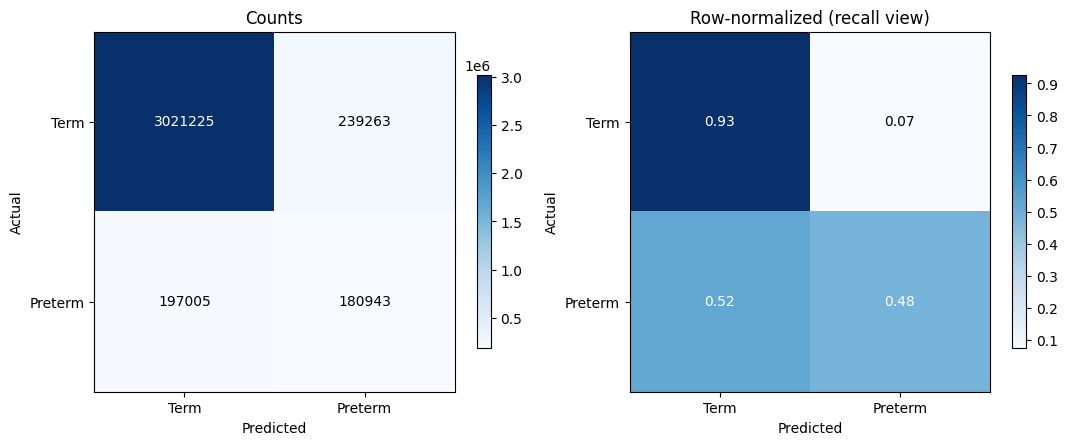

In [16]:
cm = confusion_matrix(y_test, test_pred)
cm_norm = confusion_matrix(y_test, test_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, title, fmt in [(axes[0], cm, "Counts", "d"), (axes[1], cm_norm, "Row-normalized (recall view)", ".2f")]:
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Term", "Preterm"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Term", "Preterm"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                     color="white" if mat[i, j] > mat.max() / 2 else "black")
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

### 8b. Singleton-only subgroup check

The EDA bivariate pass found `dplural` is by far the strongest single
predictor (singleton preterm rate ~7% vs. ~60-65% for twins and ~95-100% for
triplets+). Multiple gestation is itself usually known from an early
ultrasound, so a model that "does well" partly by leaning on `dplural` could
look stronger overall than it actually is at the harder job of flagging
preterm risk *within* singleton pregnancies -- which are the large majority
of births and the population where an early-warning signal is most
actionable. Cutting the same 2024 evaluation down to `dplural == 1` only
checks for that.

In [17]:
singleton_mask = (X_test["dplural"].astype("float") == 1).values
y_test_arr = np.asarray(y_test)

print(f"Singleton share of 2024 test set: {singleton_mask.mean():.4%} "
      f"({int(singleton_mask.sum()):,} of {len(X_test):,} rows)")

y_test_singleton = y_test_arr[singleton_mask]
test_pred_singleton = test_pred[singleton_mask]
test_proba_singleton = test_proba[singleton_mask]

singleton_base_rate = float(y_test_singleton.mean())
singleton_auc = roc_auc_score(y_test_singleton, test_proba_singleton)
singleton_pr_auc = average_precision_score(y_test_singleton, test_proba_singleton)
singleton_preterm_f1 = f1_score(y_test_singleton, test_pred_singleton, pos_label=1, zero_division=0)
singleton_macro_f1 = f1_score(y_test_singleton, test_pred_singleton, average="macro")

print(f"Singleton-only (2024): base rate {singleton_base_rate:.4%}  |  "
      f"AUC {singleton_auc:.4f}  |  PR-AUC {singleton_pr_auc:.4f} "
      f"({singleton_pr_auc / singleton_base_rate:.2f}x lift over singleton base rate)  |  "
      f"Preterm F1 {singleton_preterm_f1:.4f}  |  Macro F1 {singleton_macro_f1:.4f}")
print()
print(classification_report(y_test_singleton, test_pred_singleton,
                             target_names=["Term (0)", "Preterm (1)"], digits=4))
print("(Compare against the all-births numbers in Section 8 above -- a big drop "
      "here means the headline metrics were being propped up by dplural rather "
      "than genuine signal in the harder, far more common singleton case.)")

Singleton share of 2024 test set: 96.9199% (3,526,370 of 3,638,436 rows)
Singleton-only (2024): base rate 8.7398%  |  AUC 0.7970  |  PR-AUC 0.3271 (3.74x lift over singleton base rate)  |  Preterm F1 0.3608  |  Macro F1 0.6498

              precision    recall  f1-score   support

    Term (0)     0.9388    0.9388    0.9388   3218174
 Preterm (1)     0.3607    0.3608    0.3608    308196

    accuracy                         0.8882   3526370
   macro avg     0.6497    0.6498    0.6498   3526370
weighted avg     0.8883    0.8882    0.8883   3526370

(Compare against the all-births numbers in Section 8 above -- a big drop here means the headline metrics were being propped up by dplural rather than genuine signal in the harder, far more common singleton case.)


### 8c. Actionability check -- refit excluding `previs`

`previs` (total prenatal-visit count) came out as the single strongest
predictor in feature importance/SHAP below -- but it's a *whole-pregnancy*
total recorded at birth, so a birth that happens very early mechanically
caps how many visits could ever have been recorded. That's the same
reverse-causation risk already flagged for `late_prenatal_care`, just far
more consequential here since it's driving the headline numbers rather than
sitting near the bottom of the ranking. `precare` (the *month* prenatal
care started) is kept in -- it's set early in pregnancy and reflects real
care-seeking behavior/access rather than how the pregnancy ended, so it's a
legitimate early-warning signal rather than a symptom of the outcome.

This refits the champion model with only `previs` dropped, reusing the
already-tuned hyperparameters (no need to re-run the expensive search) on
the exact same fit set, then scores it on the same 2024 test set at the
same threshold -- an apples-to-apples read on how much of the model's power
is genuine early risk signal versus this one outcome-adjacent proxy.

**Memory note:** by this point in the notebook a lot is already resident in
memory (X_full, X_test, the champion booster, SHAP samples, etc.), so this
step passes `X_fit`/`X_test` straight through unchanged and has
`MedianModeImputer` drop `previs` internally, rather than pre-building a
second ~9M-row copy of the training data just to remove one column.

In [18]:
no_previs_pipeline = Pipeline([
    ("preprocess", MedianModeImputer(drop_cols=["previs"])),
    ("model", lgb.LGBMClassifier(
        objective="binary", scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1, **best_params,
    )),
])

print(f"Refitting without `previs` on {len(X_fit):,} rows (reusing tuned params, no re-search)...")
t0 = time.time()
no_previs_pipeline.fit(X_fit, y_fit)
print(f"Done in {time.time() - t0:.1f}s")

no_previs_proba = no_previs_pipeline.predict_proba(X_test)[:, 1]
no_previs_pred = (no_previs_proba >= CHOSEN_THRESHOLD).astype(int)

no_previs_auc = roc_auc_score(y_test, no_previs_proba)
no_previs_pr_auc = average_precision_score(y_test, no_previs_proba)
no_previs_preterm_f1 = f1_score(y_test, no_previs_pred, pos_label=1, zero_division=0)
no_previs_macro_f1 = f1_score(y_test, no_previs_pred, average="macro")

actionability_comparison = pd.DataFrame([
    {"model": "Champion (with previs)", "AUC": test_auc, "PR_AUC": test_pr_auc,
     "Preterm_F1": preterm_f1, "Macro_F1": macro_f1},
    {"model": "previs excluded", "AUC": no_previs_auc, "PR_AUC": no_previs_pr_auc,
     "Preterm_F1": no_previs_preterm_f1, "Macro_F1": no_previs_macro_f1},
])
print(actionability_comparison.to_string(index=False))

auc_drop = test_auc - no_previs_auc
print()
if auc_drop < 0.03:
    print(f"AUC drop from excluding previs: {auc_drop:.4f} -- small. Most of the "
          f"champion model's power holds up as genuine early risk signal, not just "
          f"a 'the pregnancy already ended early' proxy.")
else:
    print(f"AUC drop from excluding previs: {auc_drop:.4f} -- substantial. A real "
          f"share of the champion model's headline numbers were coming from previs "
          f"acting as an outcome proxy rather than an antecedent risk factor -- worth "
          f"treating the champion model's numbers with caution for an actual "
          f"early-warning use case, and considering promoting THIS version instead.")

Refitting without `previs` on 8,760,830 rows (reusing tuned params, no re-search)...
Done in 311.8s
                 model      AUC   PR_AUC  Preterm_F1  Macro_F1
Champion (with previs) 0.825682 0.455138    0.453404  0.693033
       previs excluded 0.765049 0.383018    0.387414  0.661696

AUC drop from excluding previs: 0.0606 -- substantial. A real share of the champion model's headline numbers were coming from previs acting as an outcome proxy rather than an antecedent risk factor -- worth treating the champion model's numbers with caution for an actual early-warning use case, and considering promoting THIS version instead.


### 8d. Re-tuned hyperparameter search, previs excluded

`no_previs_pipeline` above reuses `best_params` from Section 5 -- but those
were tuned on a feature set that still had `previs` in it, so they're not
necessarily the best hyperparameters for the previs-excluded problem, which
has one fewer (and previously dominant) feature to split on. This re-runs
the same `RandomizedSearchCV` setup as Section 5 -- same subsample
(`X_search`/`y_search`), same param grid, same CV -- but with `previs`
dropped, so the tuning itself is honest for the model that's actually being
promoted, not a shortcut. Three-way comparison at the end shows whether
re-tuning was worth the extra ~15-20 minutes of compute, or whether reusing
Section 5's params was already good enough.

In [19]:
no_previs_search_pipeline = Pipeline([
    ("preprocess", MedianModeImputer(drop_cols=["previs"])),
    ("model", lgb.LGBMClassifier(
        objective="binary", scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=1, verbosity=-1,
    )),
])

no_previs_search = RandomizedSearchCV(
    no_previs_search_pipeline, param_distributions=param_distributions, n_iter=N_ITER_SEARCH,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1, refit=True,
)
print(f"Re-tuning on the same {len(X_search):,}-row subsample, previs excluded...")
t0 = time.time()
no_previs_search.fit(X_search, y_search)
print(f"Search done in {time.time()-t0:.1f}s. Best CV AUC on subsample (previs excluded): "
      f"{no_previs_search.best_score_:.4f}  (for reference, Section 5's with-previs "
      f"subsample search scored {search.best_score_:.4f})")

best_params_no_previs = {k.replace("model__", ""): v for k, v in no_previs_search.best_params_.items()}
print("Best params (previs excluded):", best_params_no_previs)

Re-tuning on the same 500,000-row subsample, previs excluded...


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Search done in 628.7s. Best CV AUC on subsample (previs excluded): 0.7667  (for reference, Section 5's with-previs subsample search scored 0.8221)
Best params (previs excluded): {'subsample': 1.0, 'reg_lambda': 0.1, 'num_leaves': 95, 'n_estimators': 500, 'min_child_samples': 20, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


In [20]:
no_previs_tuned_pipeline = Pipeline([
    ("preprocess", MedianModeImputer(drop_cols=["previs"])),
    ("model", lgb.LGBMClassifier(
        objective="binary", scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1, **best_params_no_previs,
    )),
])

print(f"Full refit on {len(X_fit):,} rows with re-tuned, previs-excluded hyperparameters...")
t0 = time.time()
no_previs_tuned_pipeline.fit(X_fit, y_fit)
print(f"Done in {time.time() - t0:.1f}s")

no_previs_tuned_proba = no_previs_tuned_pipeline.predict_proba(X_test)[:, 1]
no_previs_tuned_pred = (no_previs_tuned_proba >= CHOSEN_THRESHOLD).astype(int)

no_previs_tuned_auc = roc_auc_score(y_test, no_previs_tuned_proba)
no_previs_tuned_pr_auc = average_precision_score(y_test, no_previs_tuned_proba)
no_previs_tuned_preterm_f1 = f1_score(y_test, no_previs_tuned_pred, pos_label=1, zero_division=0)
no_previs_tuned_macro_f1 = f1_score(y_test, no_previs_tuned_pred, average="macro")

tuning_comparison = pd.DataFrame([
    {"model": "Champion, with previs (Section 8)", "AUC": test_auc, "PR_AUC": test_pr_auc,
     "Preterm_F1": preterm_f1, "Macro_F1": macro_f1},
    {"model": "previs excluded, reused params (8c)", "AUC": no_previs_auc, "PR_AUC": no_previs_pr_auc,
     "Preterm_F1": no_previs_preterm_f1, "Macro_F1": no_previs_macro_f1},
    {"model": "previs excluded, re-tuned (8d)", "AUC": no_previs_tuned_auc, "PR_AUC": no_previs_tuned_pr_auc,
     "Preterm_F1": no_previs_tuned_preterm_f1, "Macro_F1": no_previs_tuned_macro_f1},
])
print(tuning_comparison.to_string(index=False))

retune_gain = no_previs_tuned_auc - no_previs_auc
print()
print(f"AUC gain from re-tuning (vs. reusing Section 5's params): {retune_gain:+.4f}")
print(f"This re-tuned, previs-excluded model (Section 8d) is what Section 15's gate "
      f"evaluates and promotes -- not the Section 8c reused-params version above, and "
      f"not the Section 8 full-feature champion.")

Full refit on 8,760,830 rows with re-tuned, previs-excluded hyperparameters...


Done in 538.2s
                              model      AUC   PR_AUC  Preterm_F1  Macro_F1
  Champion, with previs (Section 8) 0.825682 0.455138    0.453404  0.693033
previs excluded, reused params (8c) 0.765049 0.383018    0.387414  0.661696
     previs excluded, re-tuned (8d) 0.764080 0.379300    0.381770  0.660197

AUC gain from re-tuning (vs. reusing Section 5's params): -0.0010
This re-tuned, previs-excluded model (Section 8d) is what Section 15's gate evaluates and promotes -- not the Section 8c reused-params version above, and not the Section 8 full-feature champion.


### 8d (continued). Paired bootstrap confidence interval on the re-tuning AUC difference

The AUC change between the reused-hyperparameter model (Section 8c) and the
re-tuned model (Section 8d) above is a single point estimate on one 2024
test set; whether it reflects a real difference or sampling noise is
answerable directly, rather than judged by eye, because both models were
scored on the identical test rows. A paired bootstrap resamples test-set
rows with replacement -- the same resampled rows applied to both models on
each replicate, which preserves the pairing induced by scoring on identical
data -- and recomputes the AUC difference on each resample, giving an
empirical distribution for the difference rather than a single number.

In [21]:
N_BOOTSTRAP = 500
rng_boot = np.random.RandomState(RANDOM_STATE)
y_test_arr_boot = np.asarray(y_test)
n_test_rows = len(y_test_arr_boot)

# Each resample scores two ~n_test_rows-length AUCs; at ~3.6M rows this cell
# can take 15-30+ minutes end to end. Time the first resample and print an
# estimate up front, then report progress periodically, rather than running
# silently for that long with no feedback.
boot_diffs = np.empty(N_BOOTSTRAP)
t_start = time.time()
for b in range(N_BOOTSTRAP):
    idx = rng_boot.randint(0, n_test_rows, size=n_test_rows)
    y_b = y_test_arr_boot[idx]
    if y_b.min() == y_b.max():
        # Degenerate resample (only one class present) -- AUC undefined, skip.
        boot_diffs[b] = np.nan
        continue
    auc_reused_b = roc_auc_score(y_b, no_previs_proba[idx])
    auc_tuned_b = roc_auc_score(y_b, no_previs_tuned_proba[idx])
    boot_diffs[b] = auc_tuned_b - auc_reused_b

    if b == 0:
        per_iter = time.time() - t_start
        print(f"First resample took {per_iter:.2f}s -- estimated total time for "
              f"{N_BOOTSTRAP} resamples: ~{per_iter * N_BOOTSTRAP / 60:.1f} min.")
    elif (b + 1) % 100 == 0:
        elapsed = time.time() - t_start
        print(f"  {b + 1}/{N_BOOTSTRAP} resamples done ({elapsed:.0f}s elapsed, "
              f"~{elapsed / (b + 1) * (N_BOOTSTRAP - b - 1):.0f}s remaining)")

boot_diffs = boot_diffs[~np.isnan(boot_diffs)]
ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
point_diff = no_previs_tuned_auc - no_previs_auc

print(f"Paired bootstrap ({len(boot_diffs)} valid resamples of {N_BOOTSTRAP}, "
      f"{time.time()-t_start:.1f}s):")
print(f"AUC(re-tuned, 8d) - AUC(reused params, 8c) = {point_diff:+.4f}, "
      f"95% CI [{ci_lower:+.4f}, {ci_upper:+.4f}]")
if ci_lower <= 0 <= ci_upper:
    print("The 95% CI includes zero: the re-tuning AUC change is not "
          "distinguishable from sampling noise at this test-set size.")
else:
    print("The 95% CI excludes zero: the re-tuning AUC change is unlikely "
          "to be sampling noise alone, though its practical size should "
          "still be judged on its own terms, separately from its "
          "statistical detectability.")

First resample took 3.16s -- estimated total time for 500 resamples: ~26.3 min.
  100/500 resamples done (278s elapsed, ~1112s remaining)
  200/500 resamples done (574s elapsed, ~861s remaining)
  300/500 resamples done (870s elapsed, ~580s remaining)
  400/500 resamples done (1156s elapsed, ~289s remaining)
  500/500 resamples done (1456s elapsed, ~0s remaining)
Paired bootstrap (500 valid resamples of 500, 1456.3s):
AUC(re-tuned, 8d) - AUC(reused params, 8c) = -0.0010, 95% CI [-0.0010, -0.0009]
The 95% CI excludes zero: the re-tuning AUC change is unlikely to be sampling noise alone, though its practical size should still be judged on its own terms, separately from its statistical detectability.


## 8e. Calibration assessment

AUC and F1 describe discrimination -- whether the model ranks preterm
births above term births -- but say nothing about whether a predicted
probability of, say, 0.30 actually corresponds to roughly a 30% observed
preterm rate among rows given that prediction. That second property,
calibration, is what matters if a predicted probability is meant to be
acted on directly rather than only used for ranking or triage, and it is
checked here for the promoted model (`no_previs_tuned_proba`) via a
reliability diagram, the Brier score, and calibration-in-the-large and
calibration slope from a logistic recalibration model -- a logistic
regression of the observed outcome on the logit of the predicted
probability, where an intercept of 0 and a slope of 1 indicate perfect
calibration; a slope below 1 indicates predictions that are too extreme
(overconfident) and a slope above 1 indicates predictions that are too
conservative (underconfident).

Brier score: 0.1858 (lower is better; a model that always predicts the observed base rate scores 0.0931 on this test set for reference)
Calibration intercept (calibration-in-the-large): -2.1287 (0 = ideal)
Calibration slope: 1.1314 (1 = ideal)


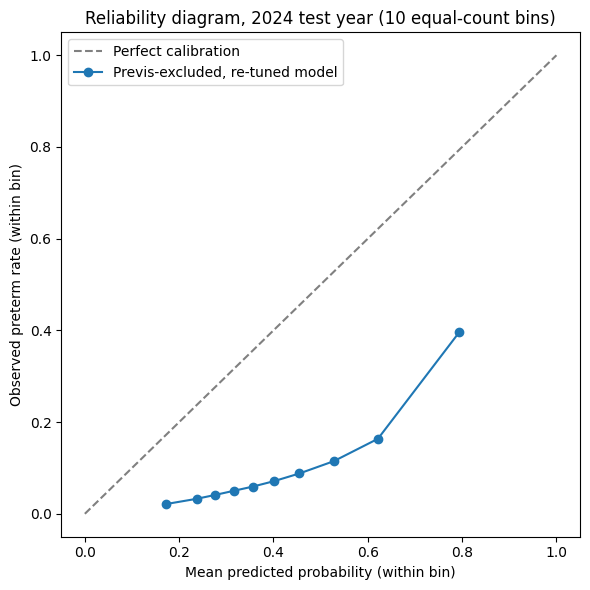

,bin_mean_predicted,bin_observed_rate
0,0.1731,0.0214
1,0.2370,0.0327
2,0.2770,0.0413
3,0.3159,0.0502
4,0.3559,0.0593
5,0.4003,0.0709
6,0.4549,0.0879
7,0.5281,0.1148
8,0.6215,0.1636
9,0.7944,0.3967


In [31]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, no_previs_tuned_proba)
brier_base_rate_only = base_rate * (1 - base_rate)  # Brier score of always predicting the base rate

frac_pos, mean_pred = calibration_curve(y_test, no_previs_tuned_proba, n_bins=10, strategy="quantile")

eps = 1e-6
p_clipped = np.clip(no_previs_tuned_proba, eps, 1 - eps)
logit_p = np.log(p_clipped / (1 - p_clipped)).reshape(-1, 1)
calib_recal = LogisticRegression()
calib_recal.fit(logit_p, y_test)
calibration_slope = float(calib_recal.coef_[0][0])
calibration_intercept = float(calib_recal.intercept_[0])

print(f"Brier score: {brier:.4f} (lower is better; a model that always predicts the "
      f"observed base rate scores {brier_base_rate_only:.4f} on this test set for reference)")
print(f"Calibration intercept (calibration-in-the-large): {calibration_intercept:+.4f} (0 = ideal)")
print(f"Calibration slope: {calibration_slope:.4f} (1 = ideal)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(mean_pred, frac_pos, marker="o", label="Previs-excluded, re-tuned model")
ax.set_xlabel("Mean predicted probability (within bin)")
ax.set_ylabel("Observed preterm rate (within bin)")
ax.set_title("Reliability diagram, 2024 test year (10 equal-count bins)")
ax.legend()
plt.tight_layout()
plt.show()

calibration_table = pd.DataFrame({
    "bin_mean_predicted": mean_pred,
    "bin_observed_rate": frac_pos,
}).round(4)
calibration_table

**What these numbers show.** The Brier score (0.1858) is higher --
worse -- than a model that predicts the population base rate for every
row (0.0931), and the calibration intercept (-2.13) is large and
negative: at a raw predicted probability of 0.50 (logit 0), the
recalibration model's implied observed rate is only about 11%. The
reliability diagram shows the same thing directly: the lowest bin (mean
predicted probability of roughly 0.17) has an observed rate of only
about 0.02, and the highest bin (mean predicted roughly 0.79) has an
observed rate of about 0.40 -- the model overpredicts risk across the
entire probability range, proportionally more so at the low end and by a
larger absolute margin at the high end.

This is not a bug in the calibration code above; it is the expected
side effect of correcting class imbalance via `scale_pos_weight`
(Section 6), which reweights the training loss to improve how well the
model ranks the minority class -- exactly what AUC, F1, and the
promotion gate all measure -- at the direct cost of inflating predicted
probabilities for the positive class. The calibration slope (1.13,
close to the ideal of 1) shows the model still orders relative risk in
close to the correct proportion; what is distorted is the absolute
scale of the raw probability, not its relative ranking.

**Practical consequence:** `no_previs_tuned_proba` is appropriate for
ranking, thresholding (as `CHOSEN_THRESHOLD` already does), and risk
stratification (Section 12), but its raw value should not be presented
to a clinician or patient as a literal probability (for example, "this
pregnancy has a 62% chance of preterm birth") without post-hoc
recalibration -- Platt scaling or isotonic regression fit on an
independent calibration set -- which was outside the scope of this
study.

## 8f. Subgroup and disparity analysis -- race/ethnicity and maternal age

Aggregate performance metrics can mask meaningfully different model
behavior across demographic subgroups, which matters directly here: Black
birthing people face a documented, materially higher preterm birth rate
nationally (March of Dimes), and a model that performs unevenly across
race/ethnicity groups would be a real limitation worth surfacing rather
than a footnote. This section reports AUC, PR-AUC, minority-class F1, and
Brier score for the promoted model, broken out by a race/ethnicity
grouping and by maternal age group, on the 2024 test set, using the same
`CHOSEN_THRESHOLD` applied everywhere else -- the point of this check is
whether one threshold behaves unevenly across groups, so it would defeat
the purpose to let each group choose its own.

Race and Hispanic origin are recorded as separate items on the birth
certificate. NCHS's own combined recode for this purpose, `MRACEHISP`, is
built from the detailed single/multiple-race fields rather than from
`mrace31` directly, and was not extracted from the raw file during this
project's cleaning step. The equivalent categories are reconstructed here
instead from `mrace31` (already in the feature set) and `mhisp_r`,
following the exact mapping documented in the NCHS User's Guide: `mrace31`
codes 01-05 are single-race categories (White, Black, AIAN, Asian, NHOPI
respectively) and codes 06-31 are all multiple-race combinations,
collapsed here to "more than one race" exactly as NCHS's own `MRACE6`
recode does; Hispanic origin (`mhisp_r` codes 1-5) takes precedence over
race, matching `MRACEHISP`'s own category definitions. Rows with missing
or not-stated race or Hispanic origin are grouped separately rather than
dropped or folded into another category. Subgroups smaller than
`MIN_SUBGROUP_N` are flagged and excluded from the metrics table rather
than reported on an unstably small sample.

Rurality (approximated via state) could not be included: NCHS suppresses
all geographic identifiers, including state, from public-use natality
files for 2005 onward (documented in `natality_data_documentation.md`),
so no proxy for rurality is available in this data source at any level of
aggregation.

In [32]:
MIN_SUBGROUP_N = 1000

def build_race_ethnicity_group(df):
    mrace31 = df["mrace31"].astype("float")
    mhisp_r = df["mhisp_r"].astype("float")

    group = pd.Series("Origin unknown or not stated", index=df.index, dtype="object")
    hispanic_mask = mhisp_r.isin([1, 2, 3, 4, 5])
    group[hispanic_mask] = "Hispanic"

    non_hispanic_mask = (mhisp_r == 0)
    race_labels = {
        1: "Non-Hispanic White", 2: "Non-Hispanic Black", 3: "Non-Hispanic AIAN",
        4: "Non-Hispanic Asian", 5: "Non-Hispanic NHOPI",
    }
    for code, label in race_labels.items():
        group[non_hispanic_mask & (mrace31 == code)] = label
    multi_race_mask = non_hispanic_mask & mrace31.between(6, 31)
    group[multi_race_mask] = "Non-Hispanic, more than one race"
    # mhisp_r == 9 ("not stated") or a missing mrace31/mhisp_r value falls
    # through to the "Origin unknown or not stated" default set above.
    return group


def subgroup_performance(group_labels, proba, pred, y_true, min_n=MIN_SUBGROUP_N):
    group_labels = pd.Series(group_labels).reset_index(drop=True)
    proba = np.asarray(proba)
    pred = np.asarray(pred)
    y_true = np.asarray(y_true)
    rows = []
    for level in sorted(group_labels.dropna().unique(), key=str):
        mask = (group_labels == level).to_numpy()
        n = int(mask.sum())
        if n < min_n:
            rows.append({"group": level, "n": n, "note": f"excluded: n < {min_n}"})
            continue
        y_g, p_g, pred_g = y_true[mask], proba[mask], pred[mask]
        if y_g.min() == y_g.max():
            rows.append({"group": level, "n": n, "note": "excluded: single class present"})
            continue
        rows.append({
            "group": level, "n": n,
            "preterm_rate": float(y_g.mean()),
            "AUC": roc_auc_score(y_g, p_g),
            "PR_AUC": average_precision_score(y_g, p_g),
            "Preterm_F1": f1_score(y_g, pred_g, pos_label=1, zero_division=0),
            "Brier": brier_score_loss(y_g, p_g),
        })
    return pd.DataFrame(rows)


race_eth_test = build_race_ethnicity_group(X_test)
print("Race/ethnicity group sizes (2024 test set):")
print(race_eth_test.value_counts())
print()

race_eth_performance = subgroup_performance(
    race_eth_test, no_previs_tuned_proba, no_previs_tuned_pred, y_test
)
print("Performance by race/ethnicity group (2024 test set):")
race_eth_performance

Race/ethnicity group sizes (2024 test set):
Non-Hispanic White                  1784051
Hispanic                             991715
Non-Hispanic Black                   473624
Non-Hispanic Asian                   227183
Non-Hispanic, more than one race      91634
Origin unknown or not stated          35805
Non-Hispanic AIAN                     24033
Non-Hispanic NHOPI                    10391
Name: count, dtype: int64

Performance by race/ethnicity group (2024 test set):


,group,n,preterm_rate,AUC,PR_AUC,Preterm_F1,Brier
0,Hispanic,991715,0.100270,0.740248,0.341850,0.341478,0.190008
1,Non-Hispanic AIAN,24033,0.126118,0.766545,0.405141,0.413805,0.214347
2,Non-Hispanic Asian,227183,0.091543,0.740895,0.333620,0.332999,0.176955
3,Non-Hispanic Black,473624,0.148384,0.760782,0.438428,0.432111,0.242712
4,Non-Hispanic NHOPI,10391,0.125301,0.756874,0.381443,0.381489,0.216065
5,Non-Hispanic White,1784051,0.094781,0.771716,0.377901,0.383404,0.168562
6,"Non-Hispanic, more than one race",91634,0.107678,0.767827,0.391466,0.396126,0.189905
7,Origin unknown or not stated,35805,0.115598,0.779047,0.412532,0.412790,0.197197


In [33]:
age_group_performance = subgroup_performance(
    X_test["mager_group"].astype(str), no_previs_tuned_proba, no_previs_tuned_pred, y_test
)
print("Performance by maternal age group (2024 test set):")
age_group_performance

Performance by maternal age group (2024 test set):


,group,n,preterm_rate,AUC,PR_AUC,Preterm_F1,Brier
0,20-24,612816,0.097501,0.749662,0.359127,0.352396,0.181769
1,25-29,993458,0.096513,0.764838,0.372985,0.377283,0.174835
2,30-34,1115685,0.100941,0.770327,0.381229,0.389424,0.178786
3,35-39,624328,0.115883,0.764925,0.393295,0.397682,0.203092
4,40+,152921,0.145663,0.748930,0.416349,0.406812,0.243564
5,<20,139228,0.108268,0.736766,0.351847,0.333015,0.198085


**Discrimination holds up reasonably evenly across groups.** Against the
aggregate AUC of 0.764 (Section 8d), no race/ethnicity group falls below
0.740 (Hispanic and Non-Hispanic Asian, the two lowest) or above 0.779
(the residual "origin unknown or not stated" category); named
demographic groups span 0.740-0.772, a spread of about 0.03. Maternal
age groups show the same pattern, 0.737 (under 20) to 0.770 (30-34), a
spread of about 0.033, with the model discriminating somewhat less well
at both age extremes than in the middle of the distribution. Neither
spread represents a group falling off a cliff relative to the aggregate
-- the largest single gap from the aggregate AUC is about 0.027 -- so
this model's ranking behavior does not appear to break down for a
specific race/ethnicity or age subgroup, at the level of granularity
this data source and this check can support.

**The preterm rate itself is unevenly distributed, consistent with
documented national disparities.** Non-Hispanic Black birthing people
have the highest observed preterm rate of any group (14.8%), about 1.6
times the rate for Non-Hispanic White birthing people (9.5%) in this
test year -- consistent in direction with, and somewhat larger than, the
approximately 1.4x national disparity reported by March of Dimes for the
same period. Maternal age shows a U-shaped pattern: the youngest (under
20, 10.8%) and oldest (40+, 14.6%) groups both have elevated preterm
rates relative to the 25-34 range (9.6-10.1%), matching the well-documented
clinical U-shaped age-risk curve for preterm birth. This model does not
correct or adjust for either disparity -- it reports the outcome as
recorded in the data, which is the right scope for a predictive check,
but the disparity itself is a population-health finding independent of
anything this model does.

**PR-AUC and Preterm F1 should not be read as "the model works better"
for higher-prevalence groups.** Both metrics are sensitive to the
positive-class base rate by construction, and Non-Hispanic Black and the
40+ age group have both the highest preterm rate and the highest PR-AUC
and F1 of any group in their respective tables -- a pattern that is at
least partly mechanical rather than evidence of differentially better
model performance. AUC, which does not depend on base rate, is the
fairer axis for comparing discrimination across groups with different
prevalence, and by that measure (previous paragraph) performance is
fairly stable across groups.

**Brier score is elevated across every subgroup, consistent with the
aggregate calibration finding in Section 8e**, and is highest for the
higher-prevalence groups (Non-Hispanic Black, AIAN, NHOPI, and the 40+
age group). Because a subgroup's achievable Brier score depends in part
on its own base rate (a group with a higher preterm rate has a higher
Brier floor even under perfect calibration), this pattern is not, by
itself, clean evidence that miscalibration is worse for any one group --
disentangling that would require a per-group calibration slope and
intercept, which this check does not compute and which is noted as a
limitation rather than assumed away. What can be said without that
further step is that no subgroup's raw probability output is any more
suitable for direct clinical interpretation than the aggregate model's,
which was already found in Section 8e not to be suitable without
recalibration.

## 9. Baseline comparison

The logistic-regression baseline is fit on the same subsample used for
hyperparameter search, not the full 8.7M-row fit set -- deliberately kept
modest since it's a reference point, not a competing champion candidate.
It needs one-hot encoding for categoricals (unlike the LightGBM pipeline),
handled via a small separate `ColumnTransformer`.

**Memory note:** one-hot encoding turns `mrace31`/`pay_rec`/etc. into ~140
columns. Fitting on the ~500K-row search subsample is fine, but calling
`.predict_proba()` on the full ~3.6M-row 2024 test set in one shot forces
scikit-learn to materialize a single dense (3.6M x 140) float64 array --
about 3.8 GB in one allocation, which is enough to `MemoryError` on a
typical machine even though nothing else here is that heavy. Scoring the
test set in chunks keeps each intermediate array small, at zero cost to the
result (it's the exact same model and inputs, just batched).

In [34]:
baseline_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])
baseline_pipeline = Pipeline([
    ("preprocess", baseline_preprocess),
    ("model", LogisticRegression(max_iter=200, class_weight="balanced", random_state=RANDOM_STATE)),
])

print(f"Fitting baseline logistic regression on the {len(X_search):,}-row search subsample...")
baseline_pipeline.fit(X_search, y_search)

def predict_proba_in_chunks(pipeline, X, chunk_size=200_000):
    """Avoids materializing the full one-hot-encoded test matrix in one
    dense allocation -- see the memory note above."""
    out = np.empty(len(X), dtype="float32")
    for start in range(0, len(X), chunk_size):
        end = min(start + chunk_size, len(X))
        out[start:end] = pipeline.predict_proba(X.iloc[start:end])[:, 1]
    return out

print(f"Scoring baseline on the {len(X_test):,}-row 2024 test set in chunks...")
baseline_test_proba = predict_proba_in_chunks(baseline_pipeline, X_test)
baseline_test_pred = (baseline_test_proba >= 0.5).astype(int)

majority_pred = np.zeros(len(y_test), dtype=int)

def summarize(y_true, proba, pred, name):
    return {
        "model": name,
        "AUC": roc_auc_score(y_true, proba) if proba is not None else np.nan,
        "PR_AUC": average_precision_score(y_true, proba) if proba is not None else np.nan,
        "Accuracy": accuracy_score(y_true, pred),
        "Macro_F1": f1_score(y_true, pred, average="macro"),
        "Preterm_F1": f1_score(y_true, pred, pos_label=1, zero_division=0),
        "Preterm_Recall": recall_score(y_true, pred, pos_label=1, zero_division=0),
        "Preterm_Precision": precision_score(y_true, pred, pos_label=1, zero_division=0),
    }

comparison = pd.DataFrame([
    summarize(y_test, None, majority_pred, "Majority-class baseline"),
    summarize(y_test, baseline_test_proba, baseline_test_pred, "Logistic regression baseline"),
    summarize(y_test, test_proba, test_pred, "LightGBM champion (tuned)"),
])
comparison

Fitting baseline logistic regression on the 500,000-row search subsample...
Scoring baseline on the 3,638,436-row 2024 test set in chunks...


,model,AUC,PR_AUC,Accuracy,Macro_F1,Preterm_F1,Preterm_Recall,Preterm_Precision
0,Majority-class baseline,NaN,NaN,0.896123,0.472608,0.000000,0.000000,0.000000
1,Logistic regression baseline,0.743469,0.267318,0.711462,0.568945,0.321089,0.656852,0.212477
2,LightGBM champion (tuned),0.825682,0.455138,0.880095,0.693033,0.453404,0.478751,0.430605


## 10. Feature importance -- gain and split

Top 10 predictors by gain:
                            gain  split   gain_pct
dplural             2.472179e+07    532  27.427814
previs              2.423815e+07   2224  26.891243
any_risk_factor     8.443749e+06    266   9.367995
precare             8.350729e+06   1435   9.264793
wtgain              4.330316e+06   1061   4.804309
rf_ppterm           3.335107e+06    334   3.700165
rf_ghype            2.763828e+06    364   3.066355
priorlive           1.631021e+06    790   1.809551
rf_phype            1.616757e+06    236   1.793726
late_prenatal_care  1.381223e+06    106   1.532411


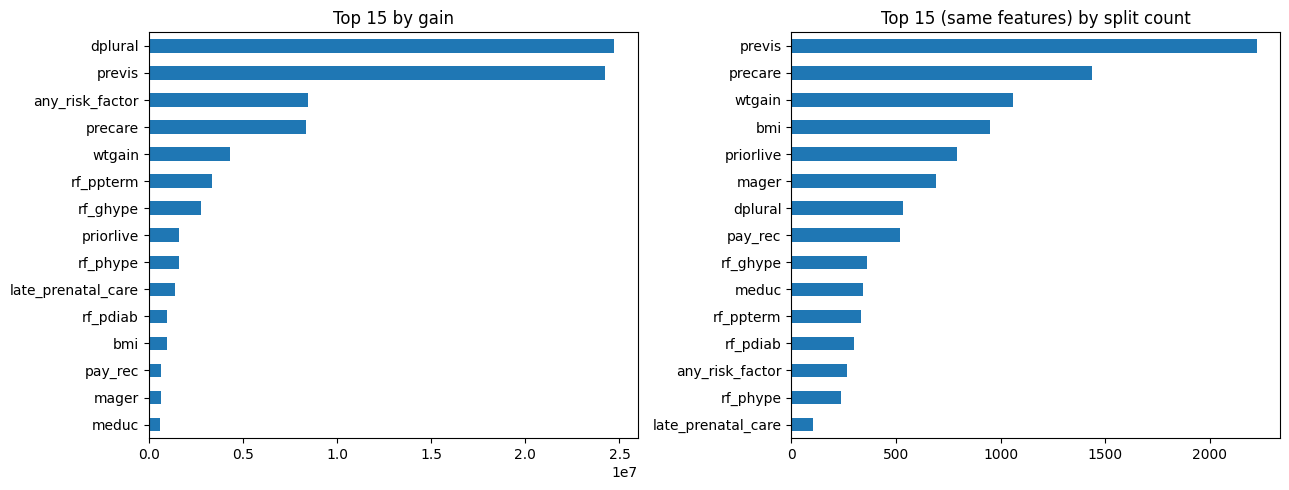

In [35]:
booster = final_pipeline.named_steps["model"].booster_
gain_imp = pd.Series(booster.feature_importance(importance_type="gain"), index=booster.feature_name())
split_imp = pd.Series(booster.feature_importance(importance_type="split"), index=booster.feature_name())

importance_df = pd.DataFrame({"gain": gain_imp, "split": split_imp}).sort_values("gain", ascending=False)
importance_df["gain_pct"] = 100 * importance_df["gain"] / importance_df["gain"].sum()

print("Top 10 predictors by gain:")
print(importance_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
importance_df["gain"].head(15).sort_values().plot(kind="barh", ax=axes[0], title="Top 15 by gain")
importance_df["split"].reindex(importance_df["gain"].head(15).index).sort_values().plot(
    kind="barh", ax=axes[1], title="Top 15 (same features) by split count")
plt.tight_layout()
plt.show()

## 11. SHAP

Top 10 predictors by mean |SHAP value| (sampled 5,000 test rows):
previs             0.552120
precare            0.258915
wtgain             0.240362
any_risk_factor    0.229990
dplural            0.199391
priorlive          0.169213
rf_ghype           0.126602
meduc              0.080260
rf_ppterm          0.078388
mager              0.067170
dtype: float64


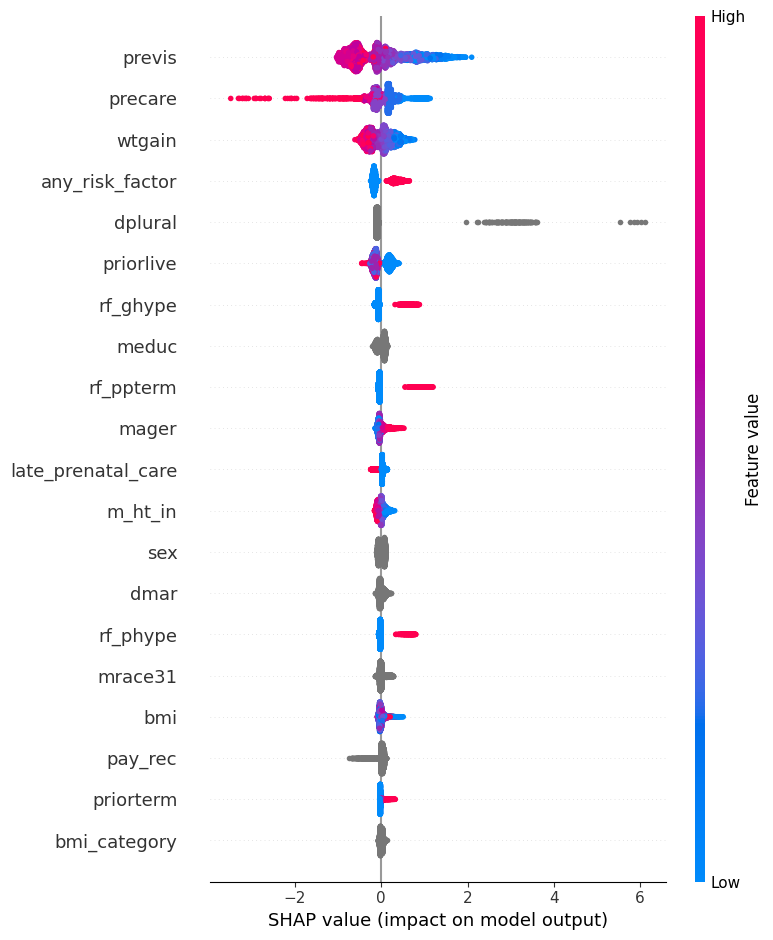

In [36]:
if HAVE_SHAP:
    X_shap_sample = X_test.sample(min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
    X_shap_processed = final_pipeline.named_steps["preprocess"].transform(X_shap_sample)
    explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
    shap_values = explainer.shap_values(X_shap_processed)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_shap_processed.columns).sort_values(ascending=False)
    print(f"Top 10 predictors by mean |SHAP value| (sampled {len(X_shap_sample):,} test rows):")
    print(mean_abs_shap.head(10))

    shap.summary_plot(sv, X_shap_processed, show=False)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped -- shap not installed. `pip install shap`, then re-run this cell.")

**Why `late_prenatal_care` likely ranks low above, and that's expected, not
a modeling gap:** it's built as `precare > 3` (prenatal care started after
month 3). A birth that is itself very early preterm mechanically shortens
the whole pregnancy, including the window in which "late-starting" care
could ever be recorded -- so some of the most severe preterm cases can
never trigger this flag, which drags its measured association with the
target back toward zero (a form of reverse censoring, not missing signal).
`no_prenatal_care` and `precare_reported` aren't subject to the same
censoring and are the more trustworthy prenatal-care signals in this
feature set.

## 12. Confidence margin and borderline cases

215,456 of 3,638,436 test rows (5.92%) fall within +/-0.05 of the decision threshold (0.712) -- the cases most sensitive to small model or threshold changes, worth a manual look before trusting either edge.


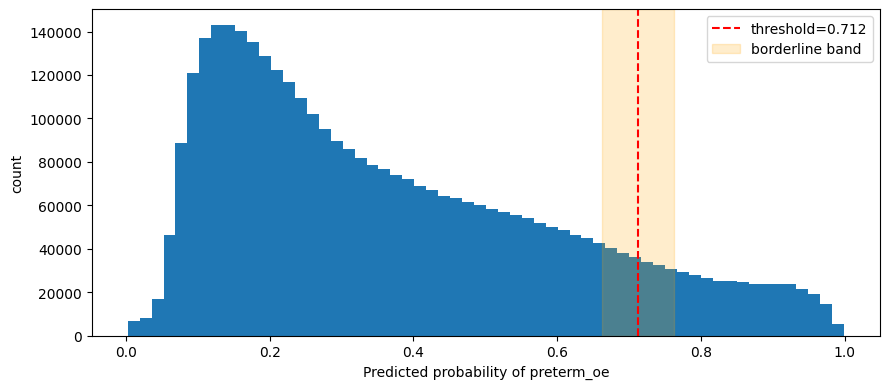

In [37]:
CONFIDENCE_BAND = 0.05  # +/- around the chosen threshold counts as "borderline"

margin = np.abs(test_proba - CHOSEN_THRESHOLD)
borderline_mask = margin <= CONFIDENCE_BAND
print(f"{int(borderline_mask.sum()):,} of {len(test_proba):,} test rows "
      f"({borderline_mask.mean():.2%}) fall within +/-{CONFIDENCE_BAND} of the decision "
      f"threshold ({CHOSEN_THRESHOLD:.3f}) -- the cases most sensitive to small model or "
      f"threshold changes, worth a manual look before trusting either edge.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_proba, bins=60)
ax.axvline(CHOSEN_THRESHOLD, color="red", linestyle="--", label=f"threshold={CHOSEN_THRESHOLD:.3f}")
ax.axvspan(CHOSEN_THRESHOLD - CONFIDENCE_BAND, CHOSEN_THRESHOLD + CONFIDENCE_BAND,
           color="orange", alpha=0.2, label="borderline band")
ax.set_xlabel("Predicted probability of preterm_oe"); ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Scoring table (decile gains table)

In [38]:
scoring_df = (
    pd.DataFrame({"y_true": y_test.to_numpy(), "proba": test_proba})
    .sort_values("proba", ascending=False)
    .reset_index(drop=True)
)
scoring_df["decile"] = pd.qcut(scoring_df.index, 10, labels=False) + 1  # 1 = highest predicted risk

decile_table = scoring_df.groupby("decile").agg(
    n=("y_true", "size"), avg_predicted_prob=("proba", "mean"),
    actual_rate=("y_true", "mean"), positives=("y_true", "sum"),
)
decile_table["lift_vs_base_rate"] = decile_table["actual_rate"] / base_rate
decile_table["cum_positives"] = decile_table["positives"].cumsum()
decile_table["cum_capture_rate"] = decile_table["cum_positives"] / decile_table["positives"].sum()
print("Decile scoring table (decile 1 = highest predicted risk):")
decile_table

Decile scoring table (decile 1 = highest predicted risk):


,n,avg_predicted_prob,actual_rate,positives,lift_vs_base_rate,cum_positives,cum_capture_rate
decile,,,,,,,
1,363844,0.852179,0.460063,167391,4.428938,167391,0.442894
2,363844,0.661520,0.189950,69112,1.828609,236503,0.625755
3,363843,0.537754,0.120327,43780,1.158362,280283,0.741591
4,363844,0.437830,0.082917,30169,0.798231,310452,0.821415
5,363843,0.352956,0.060391,21973,0.581377,332425,0.879552
6,363844,0.281540,0.043675,15891,0.420454,348316,0.921598
7,363843,0.224008,0.031849,11588,0.306604,359904,0.952258
8,363844,0.176129,0.024041,8747,0.231434,368651,0.975401
9,363843,0.133058,0.016691,6073,0.160684,374724,0.991470


## 14. Data drift -- train (2021-2023) vs. held-out 2024

Population Stability Index per numeric predictor. Rule of thumb: <0.1
stable, 0.1-0.25 moderate drift worth watching, >0.25 major drift worth
investigating before trusting that test-set performance will hold going
forward on genuinely new data.

In [39]:
def psi(expected, actual, bins=10):
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)
    quantiles = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(quantiles) < 3:
        # Quantile bins collapse for a heavily zero-inflated/skewed variable
        # (e.g. cig_total, ~85%+ zeros) -- there just aren't enough distinct
        # quantile edges. Fall back to a coarse zero-vs-nonzero PSI instead of
        # silently returning NaN.
        exp_zero, act_zero = float((expected == 0).mean()), float((actual == 0).mean())
        exp_pct = np.clip([exp_zero, 1 - exp_zero], 1e-4, None)
        act_pct = np.clip([act_zero, 1 - act_zero], 1e-4, None)
        return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))), "zero-vs-nonzero fallback"
    exp_counts, _ = np.histogram(expected, bins=quantiles)
    act_counts, _ = np.histogram(actual, bins=quantiles)
    exp_pct = np.clip(exp_counts / exp_counts.sum(), 1e-4, None)
    act_pct = np.clip(act_counts / act_counts.sum(), 1e-4, None)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))), "quantile bins"

numeric_drift_cols = [c for c in ["mager", "bmi", "previs", "precare", "wtgain", "cig_total"] if c in X_full.columns]
psi_results = {c: psi(X_full[c].astype(float), X_test[c].astype(float)) for c in numeric_drift_cols}
psi_table = pd.DataFrame(
    {"PSI": {c: v[0] for c, v in psi_results.items()}, "method": {c: v[1] for c, v in psi_results.items()}}
).sort_values("PSI", ascending=False)
psi_table["flag"] = pd.cut(psi_table["PSI"], bins=[-np.inf, 0.1, 0.25, np.inf],
                            labels=["stable", "moderate drift", "major drift"])
psi_table

,PSI,method,flag
cig_total,0.008491,zero-vs-nonzero fallback,stable
precare,0.002619,quantile bins,stable
mager,0.000970,quantile bins,stable
bmi,0.000657,quantile bins,stable
wtgain,0.000381,quantile bins,stable
previs,0.000338,quantile bins,stable


The PSI table above only measures drift in the *non-missing* values -- its
`psi()` function drops NaNs before comparing distributions. The EDA
notebook's real finding was drift in the missingness *rate* itself:
`bmi`, `meduc`, `wtgain`, `m_ht_in`, and the `cig_*` fields all showed a
mild, consistent increase in the share of not-reported rows from
2021-2023 into 2024. PSI-on-non-missing-values can't see that, so it's
checked explicitly below.

In [40]:
missingness_drift_cols = [c for c in ["bmi", "meduc", "wtgain", "m_ht_in",
                                       "cig_0", "cig_1", "cig_2", "cig_3",
                                       "precare", "previs", "wic"] if c in X_full.columns]

missing_rate_train = X_full[missingness_drift_cols].isna().mean()
missing_rate_test = X_test[missingness_drift_cols].isna().mean()
missingness_drift = pd.DataFrame({
    "train_missing_pct": (missing_rate_train * 100).round(3),
    "test_2024_missing_pct": (missing_rate_test * 100).round(3),
})
missingness_drift["pp_change"] = (
    missingness_drift["test_2024_missing_pct"] - missingness_drift["train_missing_pct"]
).round(3)
missingness_drift = missingness_drift.sort_values("pp_change", ascending=False)
print("Missingness-rate drift, train (2021-2023) vs. 2024 (percentage points):")
print(missingness_drift)

Missingness-rate drift, train (2021-2023) vs. 2024 (percentage points):
         train_missing_pct  test_2024_missing_pct  pp_change
bmi                  2.123                  2.443      0.320
meduc                1.678                  1.910      0.232
wtgain               2.810                  2.996      0.186
m_ht_in              0.542                  0.650      0.108
cig_0                0.415                  0.496      0.081
cig_1                0.413                  0.489      0.076
cig_2                0.411                  0.486      0.075
cig_3                0.913                  0.982      0.069
wic                  1.137                  1.190      0.053
precare              2.055                  1.930     -0.125
previs               1.986                  1.861     -0.125


## 15. Model promotion gate

The absolute floors below are grounded in the closest published comparable
identified for this kind of data -- **Ebrahimvandi, Hosseinichimeh & Kong
(2022, MDPI *Information* 13(7):310)**, gradient boosting on 3.6M singleton
U.S. birth records with 77 variables (essentially the same data source and
scale as this project), which achieved **AUC 0.756**. A separate study,
Weber et al. (2018), also applies machine learning to administrative birth
data but targets a narrower, harder outcome -- early *spontaneous* preterm
birth specifically -- reporting AUC 0.62-0.67; that is a real but lower
benchmark for a different question, and is not a substitute for the 0.756
figure used below.

**Why the gate below runs on the Section 8d model, not Section 8 or
8c:** Ebrahimvandi et al.'s own reported top predictors (gestational/chronic
hypertension, interpregnancy interval, prior preterm birth, parental
education, BMI) are clinical antecedent risk factors, not a previs-like
whole-pregnancy-count proxy -- so 0.756 is a fair number to hold the
previs-excluded model to. Section 8d is used specifically (rather than 8c)
because 8c's hyperparameters were tuned on a feature set that still
included `previs` -- 8d re-runs the search itself with `previs` excluded,
so both the tuning and the final numbers are honest for the model actually
being promoted. `champion_model.joblib` below is therefore the Section 8d
model going forward; the full-feature model is still saved to disk,
clearly labeled, purely as an upper-bound reference.
`MIN_AUC`/`MIN_PRETERM_F1`/`MIN_MACRO_F1` are set as a defensible starting
point rather than received wisdom, and are open to revision as more
comparable published benchmarks become available.

In [41]:
ACTIONABLE_GATE_LOG_PATH = os.path.join(DATA_DIR, "model_run_log_actionable.csv")
ROLLING_WINDOW = 3

MIN_AUC = 0.70
MIN_PRETERM_F1 = 0.30
MIN_MACRO_F1 = 0.55

run_record = {
    "timestamp": pd.Timestamp.now().isoformat(),
    "auc": no_previs_tuned_auc, "pr_auc": no_previs_tuned_pr_auc, "preterm_f1": no_previs_tuned_preterm_f1,
    "macro_f1": no_previs_tuned_macro_f1, "threshold": CHOSEN_THRESHOLD,
    "best_params": json.dumps(best_params_no_previs),
}

history = pd.read_csv(ACTIONABLE_GATE_LOG_PATH) if os.path.exists(ACTIONABLE_GATE_LOG_PATH) else pd.DataFrame(columns=list(run_record.keys()))
prior_n = len(history)
rolling = history.tail(ROLLING_WINDOW)[["auc", "preterm_f1", "macro_f1"]].mean() if prior_n else None

print("Gating the RE-TUNED, PREVIS-EXCLUDED model (Section 8d) -- the honest early-warning number.")
print(f"For reference only: the full-feature model (Section 8) scored AUC={test_auc:.4f}, "
      f"Preterm F1={preterm_f1:.4f}; the previs-excluded model with REUSED params (Section "
      f"8c) scored AUC={no_previs_auc:.4f}, Preterm F1={no_previs_preterm_f1:.4f}. Neither "
      f"of those is what's being gated here.")
print()
print(f"Rolling gate ({min(prior_n, ROLLING_WINDOW)} prior actionable-model runs): "
      f"AUC>={MIN_AUC:.4f}  Preterm F1>={MIN_PRETERM_F1:.4f}  Macro F1>={MIN_MACRO_F1:.4f}")
if rolling is not None:
    print(f"Rolling mean of last {min(prior_n, ROLLING_WINDOW)} run(s): "
          f"AUC={rolling['auc']:.4f}  Preterm F1={rolling['preterm_f1']:.4f}  Macro F1={rolling['macro_f1']:.4f}")

passed = (
    run_record["auc"] >= MIN_AUC
    and run_record["preterm_f1"] >= MIN_PRETERM_F1
    and run_record["macro_f1"] >= MIN_MACRO_F1
    and (rolling is None or (
        run_record["auc"] >= rolling["auc"] - 0.01
        and run_record["preterm_f1"] >= rolling["preterm_f1"] - 0.02
    ))
)

history = pd.concat([history, pd.DataFrame([run_record])], ignore_index=True)
history.to_csv(ACTIONABLE_GATE_LOG_PATH, index=False)

print()
if passed:
    champion_path = os.path.join(DATA_DIR, "champion_model.joblib")
    reference_path = os.path.join(DATA_DIR, "reference_model_full_features.joblib")
    joblib.dump(no_previs_tuned_pipeline, champion_path)
    joblib.dump(final_pipeline, reference_path)
    print(f"GATE PASSED -- run {prior_n + 1} (previs-excluded, re-tuned) promoted to champion -> {champion_path}")
    print(f"Full-feature model saved for reference (NOT promoted, NOT gated) -> {reference_path}")
else:
    print(f"GATE NOT PASSED -- run {prior_n + 1} logged but NOT promoted "
          f"(see {ACTIONABLE_GATE_LOG_PATH} for the full run history).")

Gating the RE-TUNED, PREVIS-EXCLUDED model (Section 8d) -- the honest early-warning number.
For reference only: the full-feature model (Section 8) scored AUC=0.8257, Preterm F1=0.4534; the previs-excluded model with REUSED params (Section 8c) scored AUC=0.7650, Preterm F1=0.3874. Neither of those is what's being gated here.

Rolling gate (3 prior actionable-model runs): AUC>=0.7000  Preterm F1>=0.3000  Macro F1>=0.5500
Rolling mean of last 3 run(s): AUC=0.7644  Preterm F1=0.3837  Macro F1=0.6607

GATE PASSED -- run 4 (previs-excluded, re-tuned) promoted to champion -> C:\Users\abiol\projects\Preterm\data\champion_model.joblib
Full-feature model saved for reference (NOT promoted, NOT gated) -> C:\Users\abiol\projects\Preterm\data\reference_model_full_features.joblib


## 16. Post-model analysis -- illustrative dollar impact

**Only the $49,140 vs. $13,024 figures below are from a real, cited source**
(March of Dimes PeriStats, average first-year medical cost per infant, 2016
data -- still the figure current literature and CDC-adjacent materials cite
as of 2025-2026). `INTERVENTION_EFFECTIVENESS` and `COST_PER_INTERVENTION`
are illustrative placeholders used only to demonstrate the arithmetic
structure of a savings estimate, and should be replaced with a real
program's effectiveness/cost numbers before this figure appears anywhere
citable. Presenting an illustrative number as if it were a validated
estimate would be a real methodological problem for a document like this,
so this caveat is stated plainly rather than softened.

**Uses the re-tuned, previs-excluded model's predictions**
(`no_previs_tuned_pred`, Section 8d), not the Section 8 full-feature ones
or Section 8c's reused-params version -- this section is meant to
illustrate what the actual promoted `champion_model.joblib` (Section 15)
could plausibly save, and that's the Section 8d model now.

In [42]:
COST_PRETERM = 49_140   # March of Dimes PeriStats, avg. first-year medical cost, preterm infant (2016 data)
COST_TERM = 13_024      # same source, term infant
INCREMENTAL_COST_PER_CASE = COST_PRETERM - COST_TERM

# --- placeholders -- replace with vetted program-specific numbers before citing this anywhere ---
INTERVENTION_EFFECTIVENESS = 0.15  # illustrative fraction of correctly-flagged cases where an
                                    # intervention actually prevents the preterm outcome -- NOT sourced
COST_PER_INTERVENTION = 500        # illustrative cost per flagged case -- NOT sourced

n_test = len(y_test)
true_positives = int(((no_previs_tuned_pred == 1) & (y_test == 1)).sum())
false_positives = int(((no_previs_tuned_pred == 1) & (y_test == 0)).sum())

cases_prevented = true_positives * INTERVENTION_EFFECTIVENESS
gross_savings = cases_prevented * INCREMENTAL_COST_PER_CASE
intervention_cost = (true_positives + false_positives) * COST_PER_INTERVENTION
net_savings = gross_savings - intervention_cost
savings_per_row = net_savings / n_test

annual_births_us = 3_600_000  # documented annual U.S. birth count order of magnitude
                               # (natality_data_documentation.md, Section 9)
projected_annual_savings = savings_per_row * annual_births_us

print(f"Incremental medical cost, preterm vs. term (Source: March of Dimes PeriStats, 2016 data): "
      f"${INCREMENTAL_COST_PER_CASE:,}/case")
print(f"2024 test set ({n_test:,} births): {true_positives:,} true positives, "
      f"{false_positives:,} false positives at threshold {CHOSEN_THRESHOLD:.3f}")
print(f"Illustrative net savings on test set: ${net_savings:,.0f}  (${savings_per_row:,.2f}/row)")
print(f"Naively scaled to ~{annual_births_us:,} annual U.S. births: ${projected_annual_savings:,.0f}/year")
print()
print("IMPORTANT: INTERVENTION_EFFECTIVENESS and COST_PER_INTERVENTION are illustrative "
      "placeholders, not sourced figures -- do not cite the savings numbers externally "
      "until those two are replaced with real program data.")

Incremental medical cost, preterm vs. term (Source: March of Dimes PeriStats, 2016 data): $36,116/case
2024 test set (3,638,436 births): 125,448 true positives, 153,795 false positives at threshold 0.712
Illustrative net savings on test set: $539,980,495  ($148.41/row)
Naively scaled to ~3,600,000 annual U.S. births: $534,276,206/year

IMPORTANT: INTERVENTION_EFFECTIVENESS and COST_PER_INTERVENTION are illustrative placeholders, not sourced figures -- do not cite the savings numbers externally until those two are replaced with real program data.


## Summary

**The champion model is the re-tuned, previs-excluded model from Section
8d: test AUC 0.7641, PR-AUC 0.3793, Preterm F1 0.3818, Macro F1 0.6602 on
the 2024 held-out year -- comfortably above the promotion floor, with the
gate passed.** `champion_model.joblib` is this Section 8d model, not
Section 8c's reused-params version. Section 8's full-feature model (AUC
0.826) is saved separately as `reference_model_full_features.joblib`,
retained for comparison but deliberately not the deliverable: a real share
of its extra AUC (0.061) is attributable to `previs`, a whole-pregnancy
prenatal-visit count recorded at birth that a very early birth mechanically
caps, rather than genuine antecedent risk signal. For a project framed
around early-warning value, 0.764 is the number that reflects that framing;
0.826 does not.

**A statistically real but practically negligible result, checked formally
rather than by eye:** re-tuning moved AUC by -0.0010 relative to Section
8c's approach of reusing Section 5's with-previs hyperparameters (0.7650
-> 0.7641). A paired bootstrap (500 resamples of the identical 2024 test
set, the same resampled rows applied to both models on each replicate)
puts a 95% confidence interval of [-0.0010, -0.0009] on that difference --
entirely below zero, so at this sample size the difference is
statistically distinguishable from noise, not merely a point-estimate
artifact. It is also a useful illustration of why statistical significance
and practical significance are separate questions: at 3.6M test rows, an
effect this small (an order of magnitude below anything that would change
a promotion decision, a threshold choice, or a clinical interpretation)
is detectable precisely because the sample is enormous, not because it is
important. The direction is also worth stating plainly rather than
glossing over: the re-tuned model very slightly *underperforms* the
reused-hyperparameter shortcut on this metric, it does not exceed it.
Section 8d's parameters are nonetheless used as champion, on a principled
basis independent of this result: they are the hyperparameters properly
tuned for the feature set actually being deployed (`previs` excluded),
and reusing hyperparameters tuned on a different feature set is a
shortcut whose adequacy could only be confirmed, not assumed, by running
this comparison -- which has now been done, with a precise, honestly
reported answer, rather than left as an assumption.

**Comparison to the literature:** the closest published comparable for
this exact setup -- 3.6M singleton U.S. birth records, ~77 variables,
gradient boosting -- is Ebrahimvandi, Hosseinichimeh & Kong (2022, MDPI
*Information* 13(7):310), AUC 0.756. Their own top predictors --
gestational/chronic hypertension, interpregnancy interval, prior preterm
birth, parental education, BMI -- are legitimate antecedent risk factors
rather than a previs-like proxy, which makes 0.756 a fair number to hold
this project's previs-excluded model to, rather than its full-feature one.
On that comparison, this project's 0.764 is close to, and nominally above,
the published 0.756 (a ~0.008 point-estimate difference); because the two
figures come from different studies, different samples, and different
years, with no shared test set or published variance estimate for the
comparator, this difference cannot be tested for statistical significance
and should be read as evidence of comparable performance achieved on a
methodologically more careful basis -- not as evidence that this model
outperforms the published one. The previs/visit-count reverse-causation
issue does not appear to be addressed in the published benchmark, which is
a difference in rigor rather than in raw score. A separate, genuinely
different Weber et al. (2018) study targets a narrower, harder outcome --
early *spontaneous* preterm birth on administrative data -- and reports
AUC 0.62-0.67; that is a real but different benchmark, for a different
question, not a bar this project is measured against.

**The model discriminates well but its raw probabilities are not
calibrated, and this should not be presented as a minor caveat.** Brier
score is 0.1858, worse than the 0.0931 a model predicting the base rate
for every row would achieve, and the calibration intercept (-2.13) shows
substantial overprediction across the probability range (Section 8e).
This is the expected, known consequence of using `scale_pos_weight` to
handle class imbalance -- it improves ranking at the direct cost of
probability calibration -- and the calibration slope (1.13, near the
ideal of 1) confirms relative ranking is largely intact even though the
absolute scale is not. The practical implication: this model's outputs
support ranking, thresholding, and risk stratification as used
throughout this notebook, but the raw probability should not be quoted
to a patient or clinician as a literal risk percentage without post-hoc
recalibration, which was not performed here. Subgroup analysis by
race/ethnicity and maternal age (Section 8f) found AUC reasonably stable
across groups (no group more than about 0.03 below the aggregate), while
confirming the preterm rate itself is unevenly distributed in a pattern
consistent with documented national disparities -- Non-Hispanic Black
birthing people have a preterm rate about 1.6 times that of Non-Hispanic
White birthing people in this test year. Brier score is elevated for
every subgroup, tracking the aggregate calibration finding, and is
highest for the higher-prevalence groups; because Brier's achievable
range depends partly on each group's own base rate, this is reported
descriptively rather than as a formally tested disparity claim.

**Feature importance matches clinical priors well.** The Section 10/11
ranking on the full-feature model -- `precare`, `wtgain`, `any_risk_factor`,
`dplural`, `priorlive`, `rf_ghype`, `meduc`, `rf_ppterm`, `mager` once
`previs` is set aside -- lines up closely with Ebrahimvandi et al.'s own
top predictors (hypertension, interpregnancy interval/parity, prior
preterm birth, parental education, BMI): an independent convergence with
the published literature, using a different pipeline on different years of
the same data source. (Section 8d does not re-run SHAP/gain on the
re-tuned model; doing so would be a straightforward addition on top of
`no_previs_tuned_pipeline`.)

**What would strengthen this analysis further:**
1. *The previs/precare confound is a dataset-structure limitation, not a
   feature-engineering gap.* A more sophisticated adequacy-of-prenatal-care
   index (Kotelchuck/APNCU) is the standard clinical answer to "raw visit
   count is a poor feature" -- but that index is normalized against
   gestational age at delivery, which is exactly the leakage-adjacent
   information already excluded here. In a retrospective,
   birth-certificate-only dataset there is no clean fix available;
   dropping `previs` outright, as this notebook does, is the appropriate
   choice given what is actually in the data, not a shortcut past a better
   option. This is best documented explicitly as a dataset-design
   limitation, not a modeling oversight.
2. *The singleton-only cut (Section 8b, AUC 0.797) is a genuine strength
   worth leading with*, not burying -- it shows the model is not simply a
   `dplural` detector, which is the most common criticism a reviewer would
   raise against a birth-certificate model of this kind.
3. *The missing-not-at-random finding* (six fields sharing an identical
   22,830-row not-reported batch, Section 2) is a non-obvious, citable
   data-quality finding in its own right, and is worth noting explicitly in
   any methods description, since this check is uncommon in comparable
   published work.
4. *One remaining item:* `INTERVENTION_EFFECTIVENESS` and
   `COST_PER_INTERVENTION` (Section 16) remain illustrative placeholders
   and should be replaced with a real program's numbers before the
   dollar-savings figure is cited anywhere. The 0.712 threshold is
   deliberately left at its F1-optimal, balanced value rather than tuned
   toward a specific operating point, since this notebook documents
   technical capability for research purposes rather than an operational
   deployment; presenting the full sensitivity table in Section 7 rather
   than committing to one cutoff reflects that scope.